# DiamondCube

Edit `bandage`, `preference`, `diagram_mode`, `face_colors`, and the `graph_*` options before running the cells using the **v2/.venv** kernel, with GAP on `PATH`.


In [ ]:
import bce_v2 as c
from bce_v2.notebook import refresh_renderers
from IPython.display import Markdown, display

refresh_renderers()

bandage = [
    0, 4, 0,
    1, 4, 2,
    1, 0, 2,

    0, 0, 0,
    1, 0, 2,
    1, 3, 2,

    0, 0, 0,
    0, 0, 0,
    0, 3, 0,
]

preference = "memory"
diagram_mode = c.DiagramMode.OPPOSITE_CORNERS
face_colors = {
    'U': 'white', 'R': 'red', 'F': 'green',
    'D': 'yellow', 'L': 'orange', 'B': 'blue',
}

analysis = c.analyze_isotropy(bandage)
display(Markdown(
    "| Shapes | Isotropy group size | Total scrambles |\n"
    "| ---: | ---: | ---: |\n"
    f"| {analysis.loops.shape_count:,} | {analysis.group_order:,} | {analysis.colored_state_count:,} |"
))

| Shapes | Isotropy group size | Total scrambles |
| ---: | ---: | ---: |
| 110 | 2,015,539,200 | 221,709,312,000 |

Compile the staged guide. Graph rendering is a separate optional cell below.


# Solution from solved shape

This computational method covers all **2,015,539,200 reachable colored states** whose bandage shape is already the declared reference shape.

In each stage's diagrams: face centers are colored to inform you how to orient the cube before algorithm application. Blocks already solved are dark grey. The block this stage requires you to identify is colored. Striped white color indicates a white sticker, plain white indicates unsolved sticker of any color.

## Algorithms

Singmaster notation uses U/R/F/D/L/B, an apostrophe for an inverse turn, 2 for a half turn, x/y/z represent whole cube rotations 90° in the direction of an R/U/F move respectively. Structured recipes use `[A, B] = A B A⁻¹ B⁻¹`, `S^A = A⁻¹ S A`, and signed powers; a negative power executes the inverse algorithm.

| Turn sequence | Block action | Structure |
| --- | --- | --- |
| `M1: L R' U B U' R L'` | `(UBL- DFL DFR- DBL-)(BL+ DL+ DB+ DR+)` | `B^(U' R L')` |
| `M2: L R' U L U' R L2` | `(UBL UBR+)(UF BL DL)(DBL- DFL)` | `L L^(U' R) L2` |
| `M3: L R' U' B U R L'` | `(UBR- DBR- DFL DFR-)(BR+ DL+ DB+ DR+)` | `B^(U R L')` |
| `M4: L R' U' R' U R2 L'` | `(UBL- UBR)(UF BR DR)(DBR+ DFR)` | `(R' R'^U R2)^L'` |
| `M5: L R' U2 B U2 R L'` | `(UBL UBR DFL DFR)(UF+ DL+ DB+ DR+)` | `B^(U2 R L')` |
| `M6: L R' U2 L U2 R L2` | `(UBL+ DBL- DFL+ UBR- DBR)(BL DL BR)` | `L L^(U2 R) L2` |
| `M7: L R' U2 R' U2 R2 L'` | `(UBL+ DBL UBR- DBR+ DFR-)(BL BR DR)` | `((R' U2)2 R2)^L'` |
| `M8: L R2 U L U' R2 L2` | `(UBL- DBR-)(UF BL DL)(DBL- DFL)` | `L L^(U' R2) L2` |
| `M9: L' R F D F' R' L` | `(UBL- DBR+ DFR- UBR+)(BL+ DR+ BR DB)` | `D^(F' R' L)` |
| `M10: L' R F R F' R2 L` | `(UBR+ DBR+)(UF+ DR BR+)(DFL DFR+)` | `(R R^F' R2)^L` |
| `M11: L' R F' D F R' L` | `(UBL- DFL+ DBL- UBR+)(BL+ DL+ BR DB)` | `D^(F R' L)` |
| `M12: L' R F' L' F R' L2` | `(UBL- DBL-)(UF+ DL BL+)(DFL- DFR)` | `L' L'^(F R') L2` |
| `M13: L' R F2 D F2 R' L` | `(UBL- DFR+ DFL- UBR+)(UF BR DB BL)` | `D^(F2 R' L)` |
| `M14: L' R F2 L' F2 R' L2` | `(UBL+ DFR- DBR DFL+ DBL-)(BL DR DL)` | `L' L'^(F2 R') L2` |
| `M16: L' R2 F' L' F R2 L2` | `(UBL- DBL-)(UF+ DL BL+)(DBR+ DFL+)` | `L' L'^(F R2) L2` |
| `M17: L2 R F R F' R2 L2` | `(UBR+ DBR+)(UF+ DR BR+)(DBL- DFR-)` | `(R R^F' R2)^L2` |
| `M18: L2 R' U' R' U R2 L2` | `(UBR+ DBL+)(UF BR DR)(DBR+ DFR)` | `(R' R'^U R2)^L2` |
| `M19: L2 R2 F' U F U' R2 L2` | `(UBR- DFR-)(UF DR+ BR+)(DBL DBR-)` | `[F', U]^(R2 L2)` |
| `M20: L2 R2 F' U' F U R2 L2` | `(UBR+ DBR+)(UF DL+ BR+)(DBL DFL+)` | `[F', U']^(R2 L2)` |
| `M21: L R' U L' B L U' R L'` | `(UBL+ DFR- DBL- UBR+)(UF+ DB+ DR+ BL+)` | `B^((U' R)^L')` |
| `M23: L R' U2 L' B L U2 R L'` | `(UBL- DBR- UBR- DFR)(UF+ BR+ DB+ DR+)` | `B^((U2 R)^L')` |
| `M25: L' R F R F R' F2 R' L` | `(UBR- DFR-)(UF+ DL BR+)(DBL- DFL)` | `(F F^R' F2)^(R' L)` |
| `M26: L' R F R' D R F' R' L` | `(UBL- DBR- DFL DFR-)(UF+ DB BL+ DR)` | `D^(F'^R' L)` |
| `M27: L' R F' L D L' F R' L` | `(UBR- DFL DFR- DBL-)(UF DL+ BR DB+)` | `D^((F R')^L)` |
| `M31: L2 R F R U F' U' R2 L2` | `(UBL- DBL+ DBR+ UBR+ DFR+)(UF BL+)(BR+ DR)` | `(R F R F'^U' R2)^L2` |
| `M37: L2 R2 F' U L F L' U' R2 L2` | `(UBL+ DBR+ DFR- UBR+ DBL+)(UF+ BL)(BR DR+)` | `[F', U L]^(R2 L2)` |
| `M40: L2 R F R U' R U R2 F' R' L2` | `(UBL+ UBR)(UF+ BR+ BL)(DBL+ DFR+)` | `(R R^U R2)^(F' R' L2)` |
| `M43: L2 R F R U F L F2 L' U' R2 L2` | `(UBL UBR+)(BL+ BR+ DR)(DBR DFR-)` | `(R F R (F F2^L')^U' R2)^L2` |
| `M45: L2 R F R U F L F L' U' F R2 L2` | `(UBL+ DFR+)(UBR DBL-)(UF BL DR+)(BR+)(DBR-)` | `(R F R (F F^L')^U' F R2)^L2` |
| `M48: L R' U L U' R' U L' U' R2 L R' U L' U' R' U L U' R2 L2` | `(UBL- DBR UBR+)` | `L R' R'^(L'^U') (L R' R'^(L^U'))^R2 L2` |
| `M49: L' R F R F' R' F R F' R2 L' R2 F R' F' R F R' F' R' L2` | `(DBL-)(DFL+)` | `L' L'^(R2 R'^F' [R, F] R') L2` |

### Shared piece recipes

| Piece | Turn sequence |
| --- | --- |
| `C1` | `R F R'` |
| `C2` | `L R' U` |
| `C3` | `U' R' U` |
| `C4` | `R F R` |
| `C5` | `L' R F'` |
| `C6` | `F R F' R2` |
| `C7` | `F' R' L2` |
| `C8` | `L U' R2 L2` |
| `C9` | `L' U' R2` |
| `C10` | `U' R L2` |

| Algorithm | Recipe |
| --- | --- |
| `M1` | `(C2) (B) (C2)^-1` |
| `M2` | `C2 L C10` |
| `M3` | `(L R' U') (B) (L R' U')^-1` |
| `M4` | `(L) (R' C3 R2) (L)^-1` |
| `M5` | `(C2 U) (B) (C2 U)^-1` |
| `M6` | `C2 x' y' (C1) y x C10` |
| `M7` | `(L) (R' U2 R' U2 R2) (L)^-1` |
| `M8` | `L R2 U C8` |
| `M9` | `(L' R F) (D) (L' R F)^-1` |
| `M10` | `(L') (R C6) (L')^-1` |
| `M11` | `(C5) (D) (C5)^-1` |
| `M12` | `C5 L' C5^-1 L` |
| `M13` | `(C5 F') (D) (C5 F')^-1` |
| `M14` | `C5 y' (C4^-1) y C7` |
| `M16` | `L' R2 x y2 (C3) y2 x' R2 L2` |
| `M17` | `(L2) (R C6) (L2)^-1` |
| `M18` | `(L2) (R' C3 R2) (L2)^-1` |
| `M19` | `(L2 R2) (F' z (C1) z') (L2 R2)^-1` |
| `M20` | `(L2 R2) (x y (C3) y' x' U) (L2 R2)^-1` |
| `M21` | `(C2 L') (B) (C2 L')^-1` |
| `M23` | `(C2 U L') (B) (C2 U L')^-1` |
| `M25` | `(L' R) (F x2 y (C6) y' x2) (L' R)^-1` |
| `M26` | `(L' C1) (D) (L' C1)^-1` |
| `M27` | `(C5 L) (D) (C5 L)^-1` |
| `M31` | `(L2) (C4 z (C1^-1) z' R2) (L2)^-1` |
| `M37` | `(L2 R2) (F' U z2 (C1) z2 U') (L2 R2)^-1` |
| `M40` | `(C7^-1) (R C3^-1 R2) (C7^-1)^-1` |
| `M43` | `(L2) (C4 U y' (C1) y F' C9) (L2)^-1` |
| `M45` | `(L2) (C4 U y' (C4) y L' U' F R2) (L2)^-1` |
| `M48` | `C2 L C3 C9 C2 L' C3 C8` |
| `M49` | `L' C4 F' R' C6 L' C6^-1 C1 C7` |

## Stage 1: Solve Edge UF

This stage has 12 exact cases and 11 instruction families. It reduces the remaining possibilities from 2,015,539,200 to 167,961,600.

### Case 1

Skip — already correct

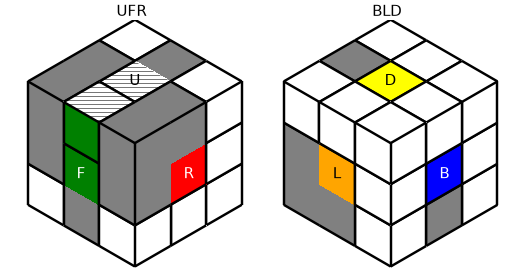

### Case 2

Execute `(M10 M4)^-1: L R2 U' R U R L2 R2 F R' F' R' L`.

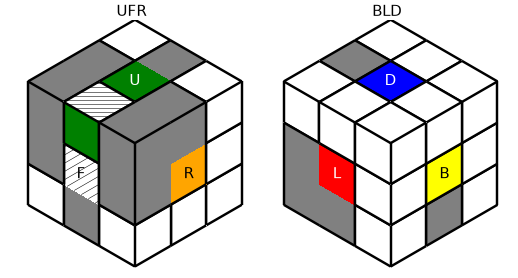

### Case 3

Execute `M10^-1: L' R2 F R' F' R' L`.

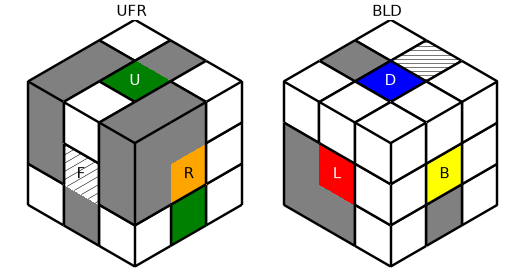

### Case 4

Execute `M4: L R' U' R' U R2 L'`.

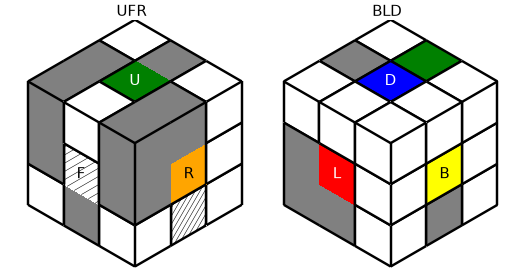

### Case 5

Execute `M12^-1: L2 R F' L F R' L`.

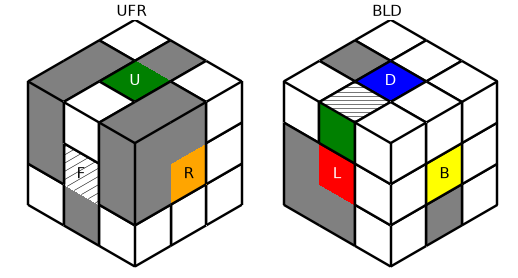

### Case 6

Execute `M2: L R' U L U' R L2`.

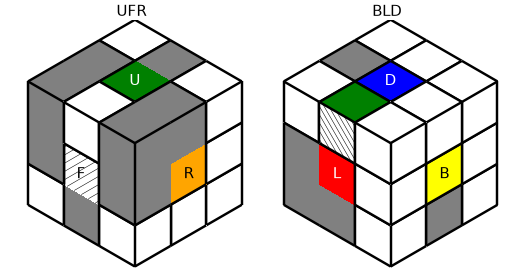

### Case 7

Execute `M13^-2: L' R F2 D2 F2 R' L`.

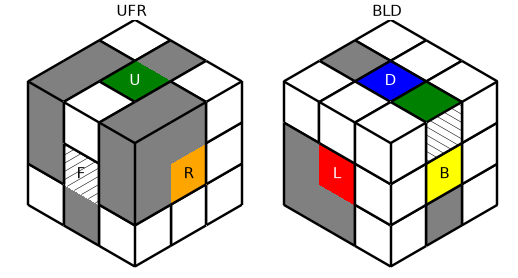

### Case 8

Execute `M27: L' R F' L D L' F R' L`.

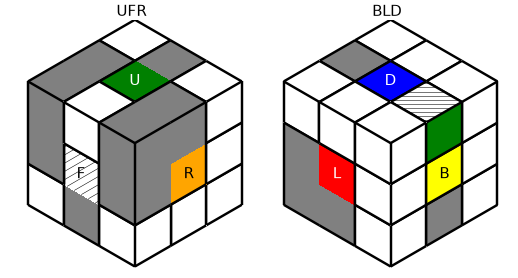

### Case 9

Execute `M10: L' R F R F' R2 L`.

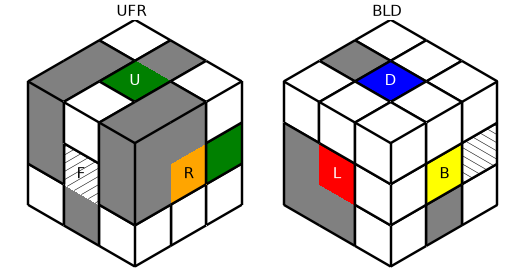

### Case 10

Execute `M4^-1: L R2 U' R U R L'`.

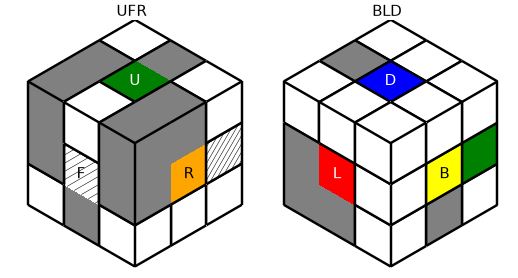

### Case 11

Execute `M12: L' R F' L' F R' L2`.

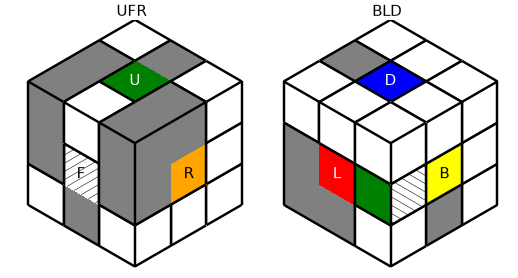

### Case 12

Execute `M2^-1: L2 R' U L' U' R L'`.

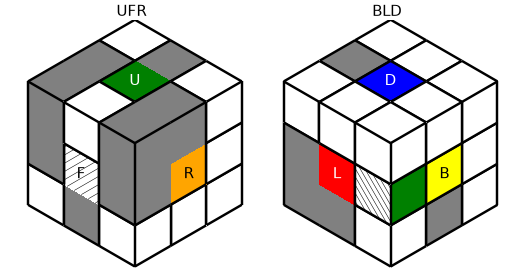

Also correct automatically after this stage: place Edge UF.

## Stage 2: Solve Edge BL

This stage has 10 exact cases and 8 instruction families. It reduces the remaining possibilities from 167,961,600 to 16,796,160.

### Case 1

Skip — already correct

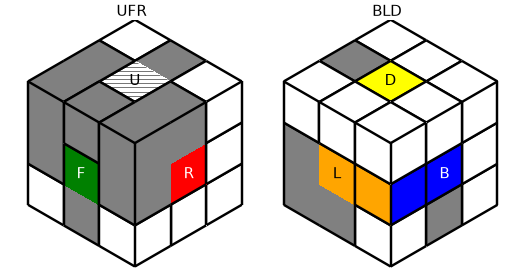

### Case 2

Execute `(M3 M7)^-1: L R2 U2 R U B' U R L'`.

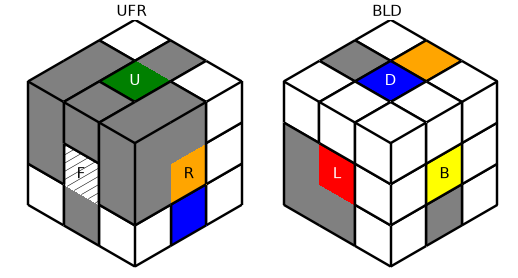

### Case 3

Execute `M3^-2: L R' U' B2 U R L'`.

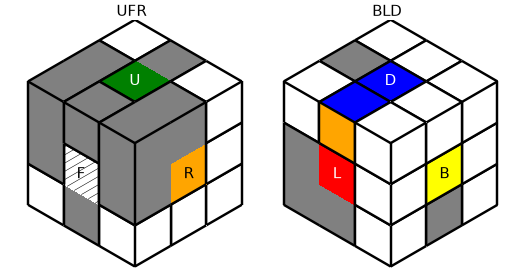

### Case 4

Execute `(M21^M2)^-1: L2 R' U L2 B' L2 U' R L2`.

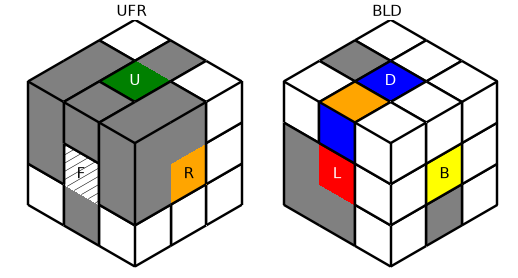

### Case 5

Execute `M3: L R' U' B U R L'`.

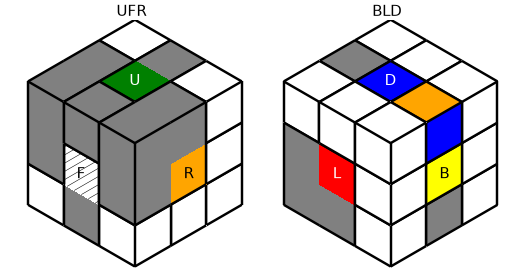

### Case 6

Execute `(M26^M10)^-1: L' R2 F R2 D' R2 F' R2 L`.

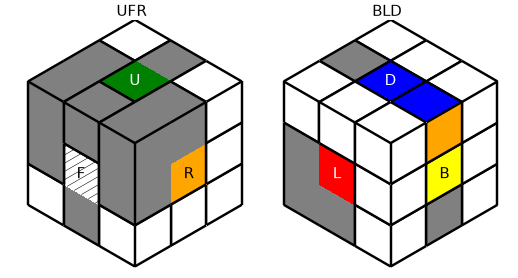

### Case 7

Execute `M7: L R' U2 R' U2 R2 L'`.

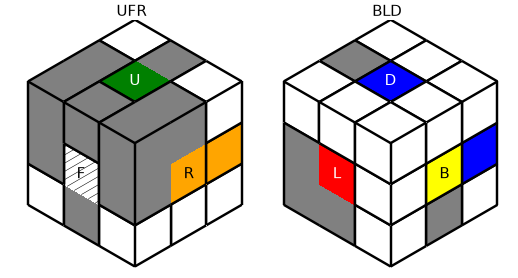

### Case 8

Execute `M3^-1: L R' U' B' U R L'`.

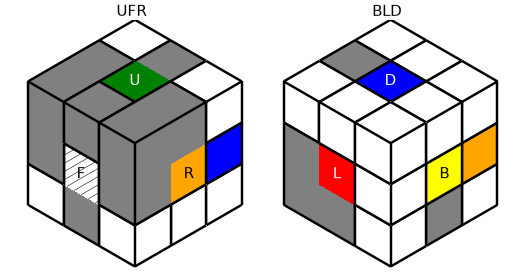

### Case 9

Execute `M14: L' R F2 L' F2 R' L2`.

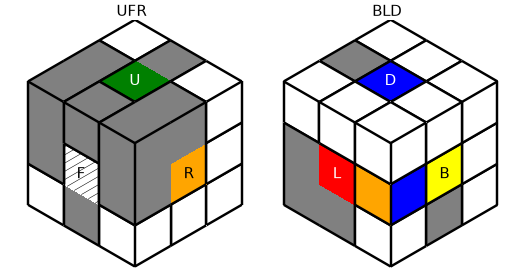

### Case 10

Execute `M9: L' R F D F' R' L`.

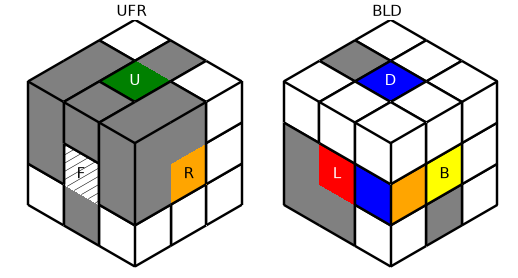

Also correct automatically after this stage: place Edge BL.

## Stage 3: Solve Edge BR

This stage has 8 exact cases and 6 instruction families. It reduces the remaining possibilities from 16,796,160 to 2,099,520.

### Case 1

Skip — already correct

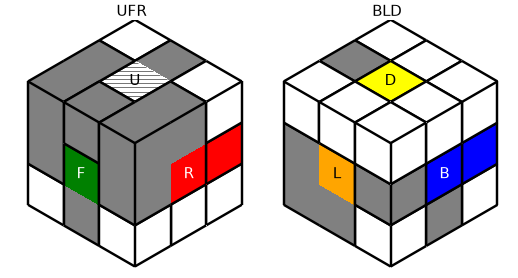

### Case 2

Execute `(M11 M6^-1)^-1: L R' U2 L U2 R L R F' D' F R' L`.

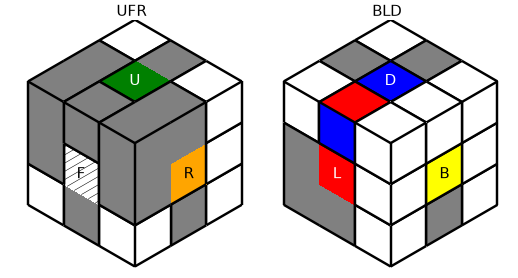

### Case 3

Execute `M11^-2: L' R F' D2 F R' L`.

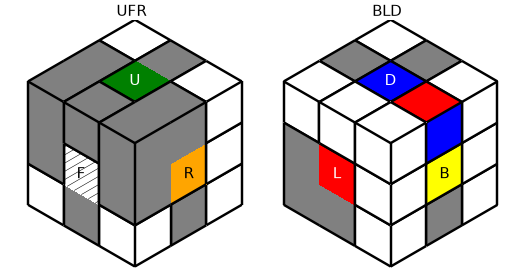

### Case 4

Execute `(M25^M13)^-1: L' R F2 D' R F' R' F D F2 R' L`.

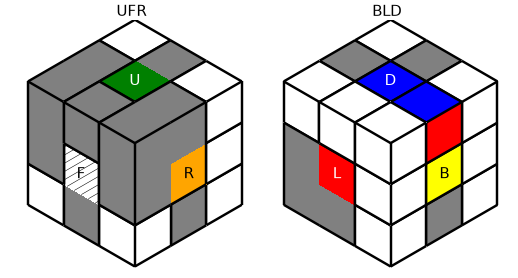

### Case 5

Execute `M6^-1: L2 R' U2 L' U2 R L'`.

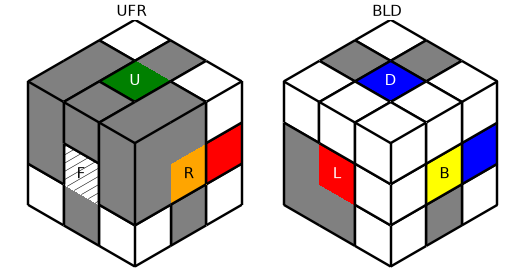

### Case 6

Execute `M11^-1: L' R F' D' F R' L`.

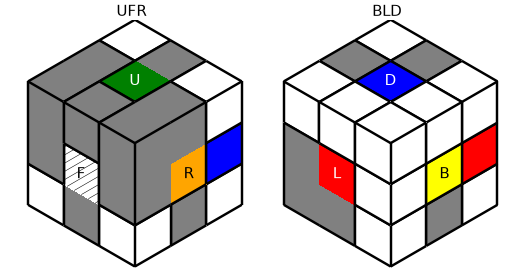

### Case 7

Execute `M6: L R' U2 L U2 R L2`.

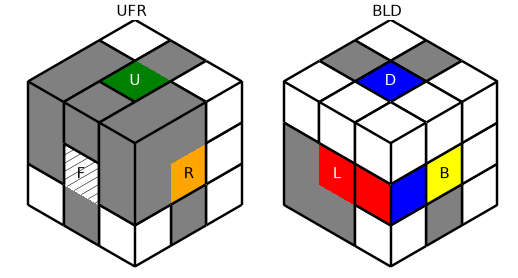

### Case 8

Execute `M11: L' R F' D F R' L`.

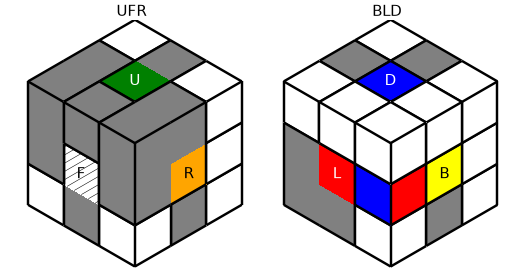

Also correct automatically after this stage: place Edge BR.

## Stage 4: Solve Edge DB

This stage has 6 exact cases and 4 instruction families. It reduces the remaining possibilities from 2,099,520 to 349,920.

### Case 1

Skip — already correct

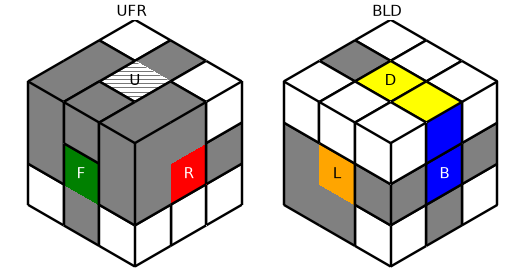

### Case 2

Execute `((((M31^-1)^(M2^-1) ([M3^-1, M5])^-1)^-1)^((M2^-1 M3^2)^-1))^-1: L2 R' U L' U2 B2 U2 L U' R' U F U' R' F' R2 U L' U B U B' U' B' U B' U2 L U' R L2`.

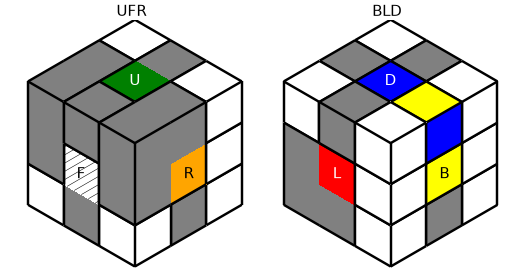

### Case 3

Execute `((M7^-1)^(M5^-1))^-1: L R' U2 B R' U2 R U2 B' U2 R L'`.

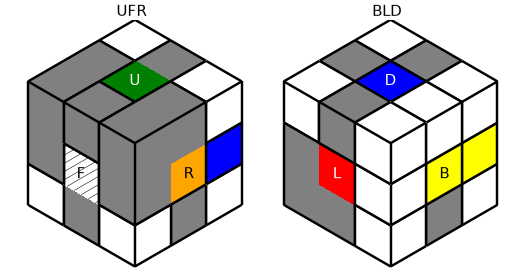

### Case 4

Execute `([M10, M12^-1]^((M11^-1 M13^-1)^-1))^-1: L' R F' D' F' D' F2 R' L' R F' L F2 R F' R' F' L' F R' L R2 F R' F D F D F R' L`.

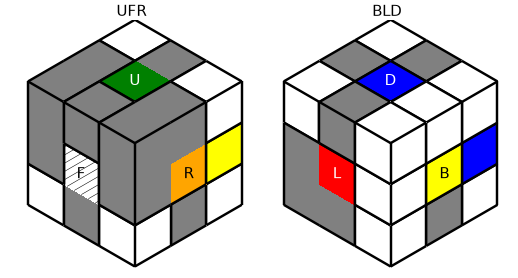

### Case 5

Execute `((M7^-1)^(M5^-1))^-2: L R' U2 B R' U2 R U2 R' U2 R U2 B' U2 R L'`.

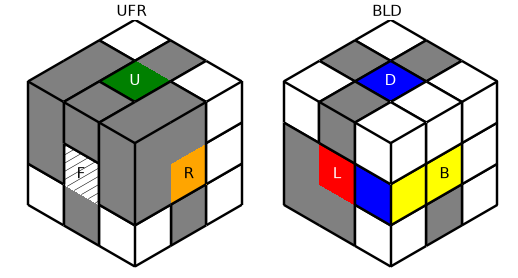

### Case 6

Execute `([M10^-1, M12^-1]^((M3^-1 M2)^-1))^-1: L R' U' B' U2 L U' R2 F' L F R F R' F2 L' F R' L R F R F' R2 L' R' U L' U2 B U R L'`.

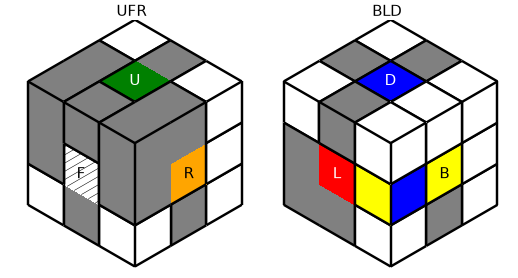

Also correct automatically after this stage: place Edge DB.

## Stage 5: Solve Edge DL

This stage has 4 exact cases and 3 instruction families. It reduces the remaining possibilities from 349,920 to 87,480.

### Case 1

Skip — already correct

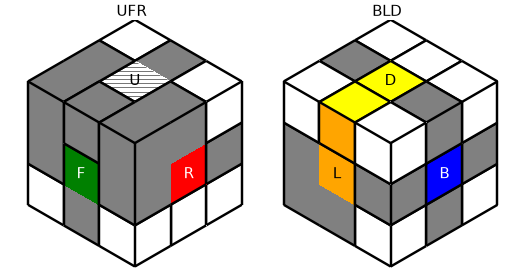

### Case 2

Execute `(((([M3^-1, M5] ((M31^-1)^(M2^-1))^-1)^M2)^-1)^((())^-1))^-1: L2 R' U L' U2 B' U' B U B U' B' U' L U' R2 F R U F' U' R2 L2`.

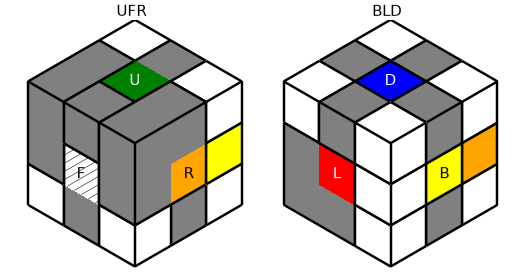

### Case 3

Execute `(M18^-1 (M4^-1)^-2 M18^-1 M2 M8^-1 M37 M31 M26 M23^-1 M9^-1 M10 M4 M5 M3^-1 M18 M4 M37^-1 M4^-1 M3 M5^-1 M4 M17 M4)^-1: L R2 U' R U R L R2 F R' F' R' L' R2 U' R U' B U B' R' U R2 L R2 F' U L F L' U' R2 L' R2 U' R U R L R2 U' R U R L' R' U' B U' B' U2 R' U' R U R L2 R2 F R' D F' R' L2 R' U2 L' B L U2 R L2 R F R' D' R F' R' L' R2 U F U' R' F' R U L F' L' U' F R2 L' R2 U L U' R U L' U' R L R' U' R' U R2 L' R2 U' R U R' U' R U R L R' U' R' U R2 L2`.

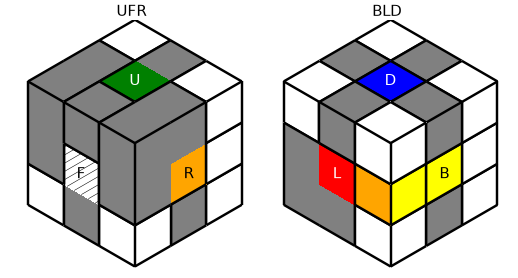

### Case 4

Execute `(M18^-1 (M4^-1)^-2 M18^-1 M17^-1 M37 M45 M26 M23^-1 M9^-1 M10 M4 M5 M3^-1 M40 M17 M3 M5^-1 M4 M17 M4)^-1: L R2 U' R U R L R2 F R' F' R' L' R2 U' R U' B U B' U R L R2 F R U' R' U R' F' R' L' R' U' B U' B' U2 R' U' R U R L2 R2 F R' D F' R' L2 R' U2 L' B L U2 R L2 R F R' D' R F' R' L' R2 F' U L F' L' F' U' R' F' R U L F' L' U' F R' F R F' R U' R' U R2 L' R2 U' R U R' U' R U R L R' U' R' U R2 L2`.

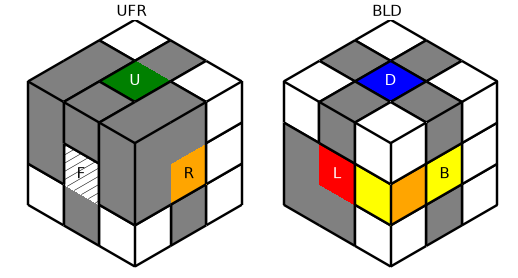

Also correct automatically after this stage: place Edge DL; place Edge DR; fully solve Edge DR.

## Stage 6: Solve Corner UBL

This stage has 18 exact cases and 16 instruction families. It reduces the remaining possibilities from 87,480 to 4,860.

### Case 1

Skip — already correct

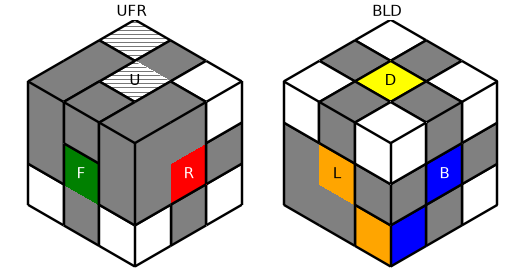

### Case 2

Execute `(M49^M10)^-1: L' R2 F R' F' R' L' R F R F' R' F R F' R2 L R2 F R' F' R' L`.

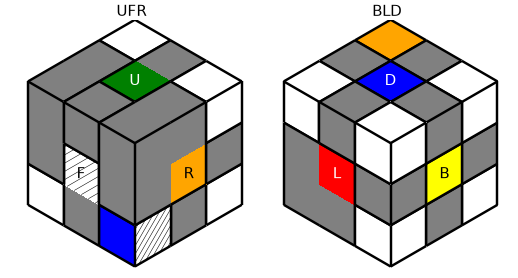

### Case 3

Execute `((M49^-1)^M10)^-1: L' R F R F' R2 L' R2 F R' F' R F R' F' R' L R F R F' R2 L`.

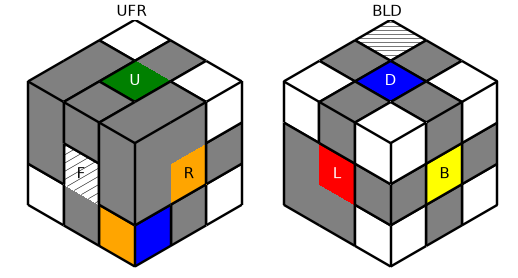

### Case 4

Execute `([M12^-1, M16])^-1: L' R2 F' L' F R' F' L F R' L' R2 F' L F R' F' L' F R' L2`.

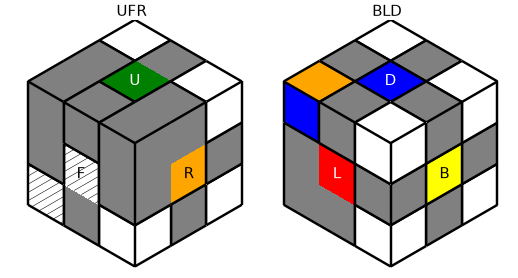

### Case 5

Execute `(M10^-1)^-3: L' R F R F' R' F R F' R' F R F' R2 L`.

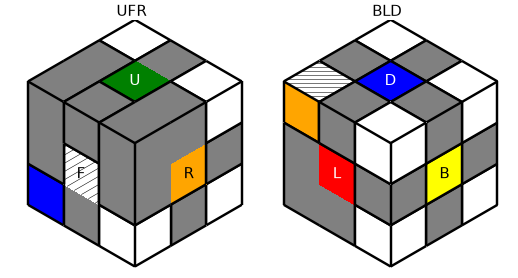

### Case 6

Execute `([M12, M16^-1])^-1: L2 R2 F' L F R' F' L' F R' L R2 F' L' F R' F' L F R' L`.

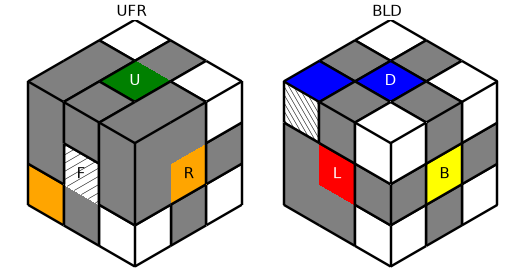

### Case 7

Execute `(M4^-1)^-3: L R' U' R' U R U' R' U R U' R' U R2 L'`.

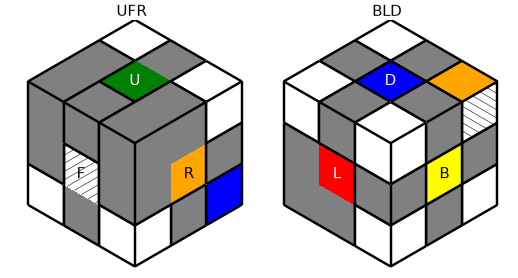

### Case 8

Execute `([M12^-1, M16]^(M12^-1))^-1: L' R F' L' F R' L R2 F' L' F R' F' L F R' L' R2 F' L F R2 L`.

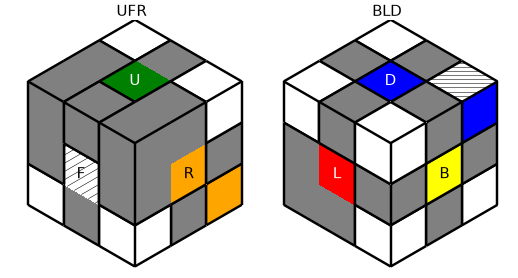

### Case 9

Execute `[M12^-1, M16]: L2 R F' L F R F' L' F R2 L R F' L' F R F' L F R2 L`.

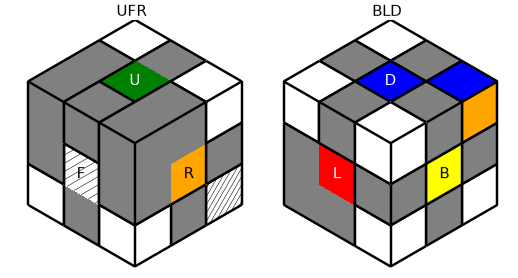

### Case 10

Execute `(M17^-1)^-3: L2 R F R F' R' F R F' R' F R F' R2 L2`.

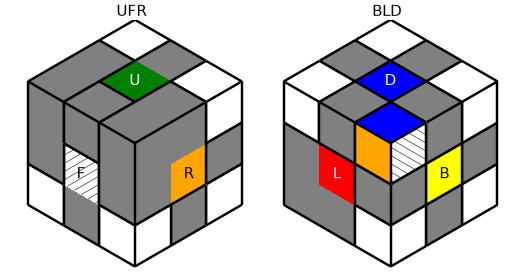

### Case 11

Execute `([M10^-1, M17])^-1: L2 R F R F' R2 L R2 F R' F' R' L' R2 F R' F' R' L R F R F' R2 L`.

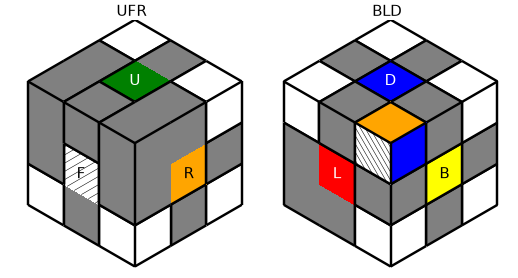

### Case 12

Execute `([M10^-1, M17^-1])^-1: L2 R2 F R' F' R' L R2 F R' F' R' L' R F R F' R2 L R F R F' R2 L`.

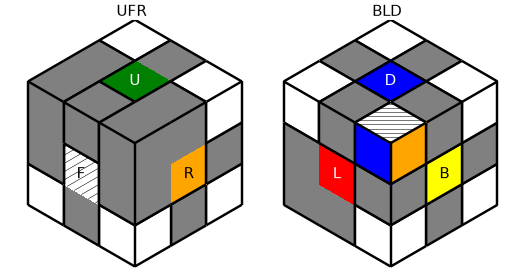

### Case 13

Execute `M19^-3: L2 R2 U F' U' F U F' U' F U F' U' F R2 L2`.

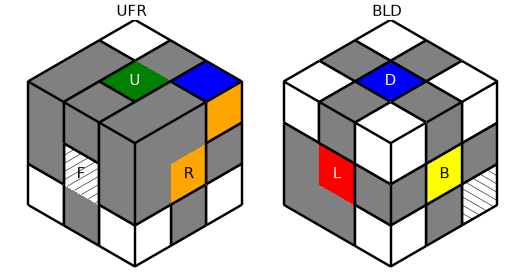

### Case 14

Execute `((M4^-1)^3 (M10^-1)^3)^-1: L' R F R F' R' F R F' R' F R F' R2 L2 R' U' R' U R U' R' U R U' R' U R2 L'`.

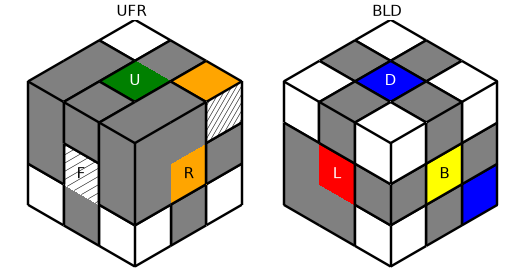

### Case 15

Execute `(M48^((M3 M8)^-1))^-1: L R' U' B U2 L U' R L' R2 U L U' R U L' U' R L R2 U L' U' R U' B' U R L'`.

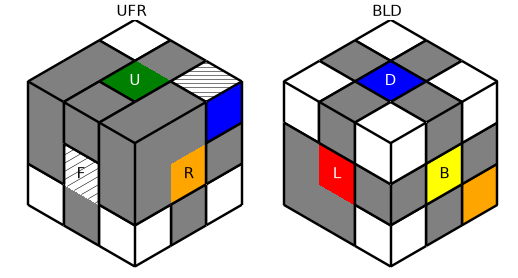

### Case 16

Execute `([M12, M16^-1]^(M11^-1))^-1: L' R F' D F R' L' R2 F' L F R' F' L' F R' L R2 F' L' F R' F' L D' F R' L`.

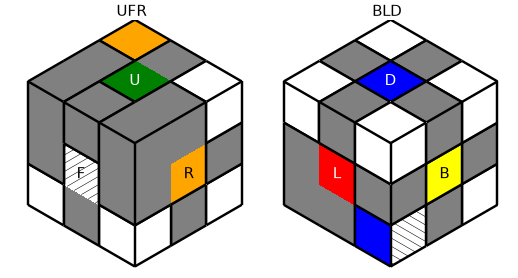

### Case 17

Execute `(M48^M4)^-1: L R2 U' R U R L R2 U L' U' R U L U' R L' R2 U L U' R U L' U2 R' U R2 L'`.

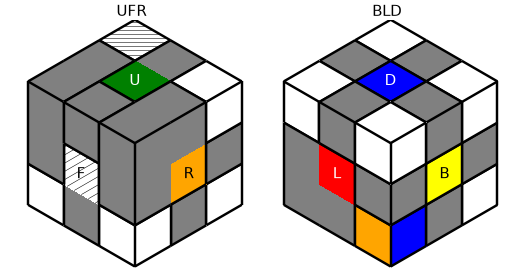

### Case 18

Execute `(M48^(M3^-1))^-1: L R' U' B U R L R2 U L' U' R U L U' R L' R2 U L U' R U L' U2 B' U R L'`.

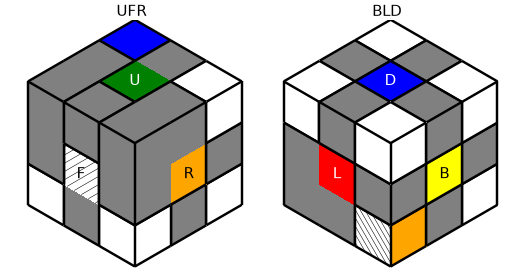

Also correct automatically after this stage: place Corner UBL.

## Stage 7: Solve Corner UBR

This stage has 15 exact cases and 14 instruction families. It reduces the remaining possibilities from 4,860 to 324.

### Case 1

Skip — already correct

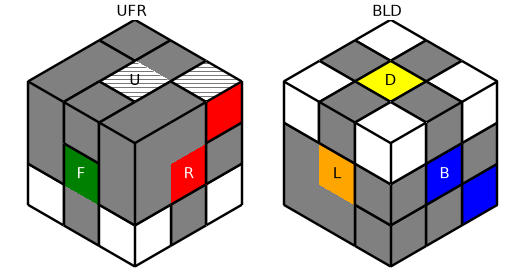

### Case 2

Execute `((M17^-1)^2 (M10^-1)^-2)^-1: L' R2 F R' F' R F R' F' R' L' R F R F' R' F R F' R2 L2`.

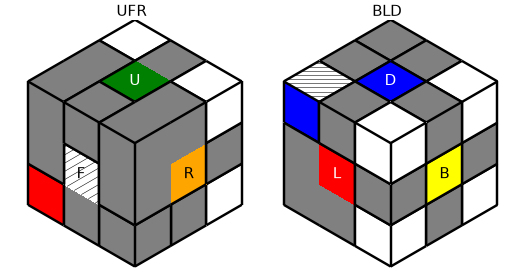

### Case 3

Execute `M49: L' R F R F' R' F R F' R2 L' R2 F R' F' R F R' F' R' L2`.

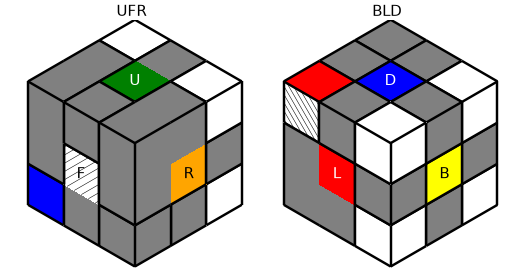

### Case 4

Execute `(M16^-1)^-3: L' R2 F' L' F R2 L R2 F' L' F R2 L R2 F' L' F R2 L2`.

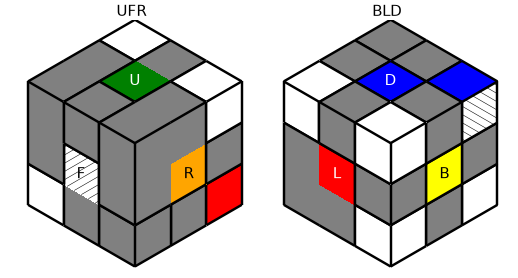

### Case 5

Execute `((M48^-1)^((M3^-1 M8)^-1))^-1: L R' U' B' U R' U L U' R2 L' R' U L U' R' U L' U' R2 L R' U L' U2 B U R L'`.

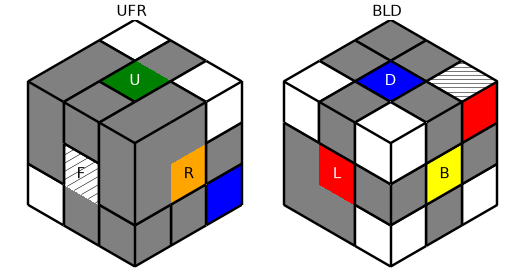

### Case 6

Execute `((M48^-1)^((M1^-1 M8)^-1))^-1: L R' U B' U' R' U L U' R2 L' R' U L U' R' U L' U' R2 L R' U L' B U' R L'`.

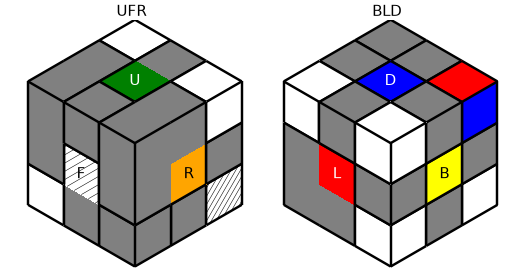

### Case 7

Execute `M20^-3: L2 R2 U' F' U F U' F' U F U' F' U F R2 L2`.

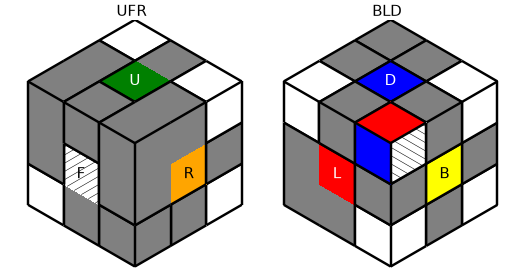

### Case 8

Execute `((M48^-1)^(M16^-1))^-1: L' R2 F' L' F R2 L' R' U L U' R' U L' U' R2 L R' U L' U' R' U L U' F' L F R2 L`.

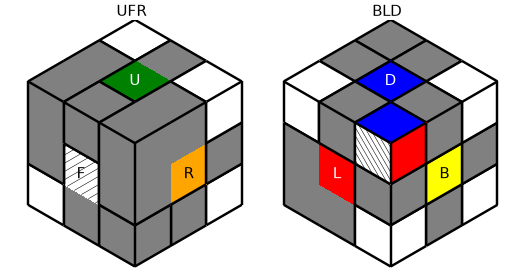

### Case 9

Execute `((([M12^-1, M16])^-1)^M17)^-1: L2 R2 F R' F2 L F R F' L' F R2 L R F' L' F R F' L F R2 L' R F R F' R2 L2`.

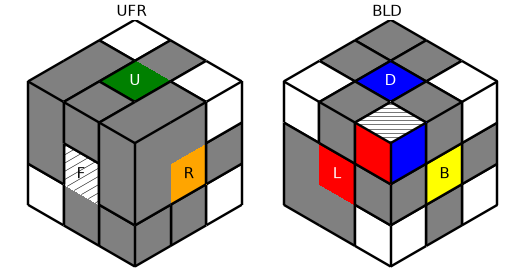

### Case 10

Execute `([M12^-1, M16]^(M9^-2))^-1: L' R F D2 F' R F' L' F R' F' L F R' L' R2 F' L F R' F' L' F R' L R F D2 F' R' L`.

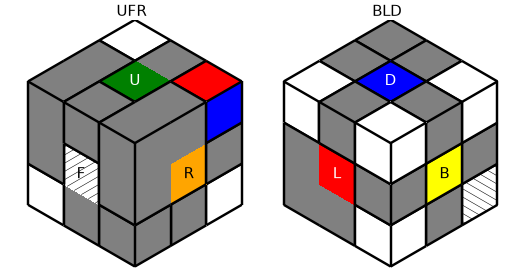

### Case 11

Execute `((M48^-1)^M1)^-1: L R' U B' L U' R' U L' U' R2 L R' U L' U' R' U L U' R2 L' R' U B U' R L'`.

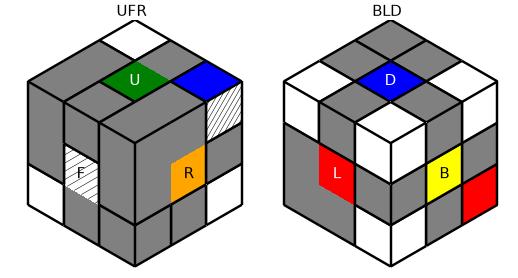

### Case 12

Execute `([M12, M16^-1]^M13)^-1: L' R F2 D' F2 R' L' R2 F' L F R' F' L' F R' L R2 F' L' F R' F' L F' D F2 R' L`.

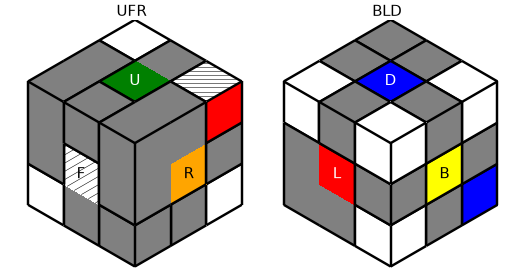

### Case 13

Execute `(M48^((M3^-1 M8)^-1))^-1: L R' U' B' U2 L U' R L' R2 U L U' R U L' U' R L R2 U L' U' R U' B U R L'`.

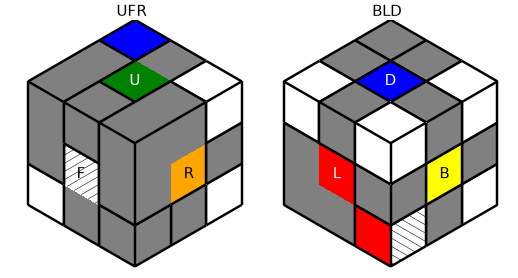

### Case 14

Execute `([M12, M16^-1]^(M1^-1))^-1: L R' U B U' R L R2 F' L F R' F' L' F R' L R2 F' L' F R' F' L F R' L2 R' U B' U' R L'`.

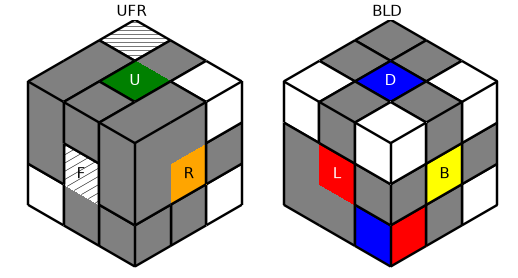

### Case 15

Execute `((M48^-1)^M3)^-1: L R' U' B' U2 L U' R' U L' U' R2 L R' U L' U' R' U L U' R2 L' R' U' B U R L'`.

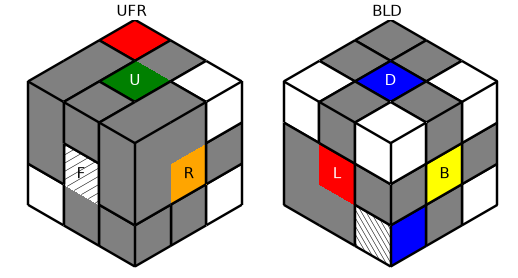

Also correct automatically after this stage: place Corner UBR.

## Stage 8: Solve Corner DBL

This stage has 12 exact cases and 10 instruction families. It reduces the remaining possibilities from 324 to 27.

### Case 1

Skip — already correct

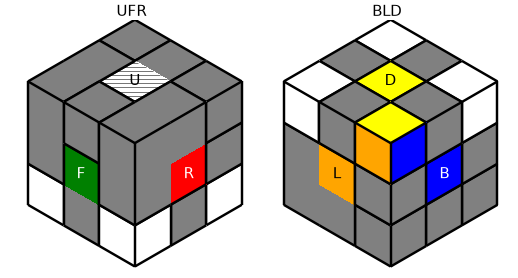

### Case 2

Execute `(M7^-1 M4 M6^-1 M2)^-1: L2 R' U L' U L U2 R L' R2 U' R U' R' U2 R2 L'`.

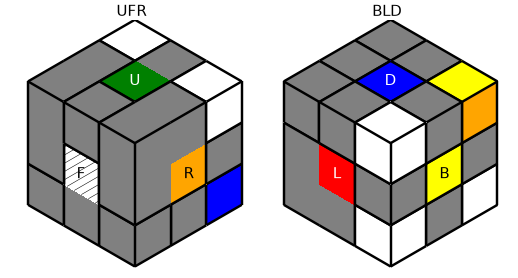

### Case 3

Execute `(M2^-1 M6 M4^-1 M7)^-1: L R2 U2 R U R' U R2 L R' U2 L' U' L U' R L2`.

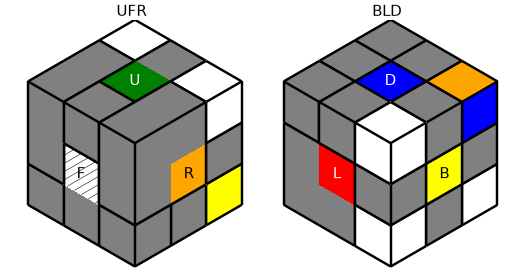

### Case 4

Execute `((M48^-1)^(M1^-1))^-1: L R' U B L U' R' U L' U' R2 L R' U L' U' R' U L U' R2 L' R' U B' U' R L'`.

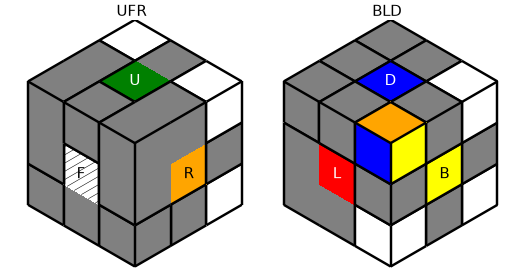

### Case 5

Execute `(M48^((M1 M8)^-1))^-1: L R' U B L U' R L' R2 U L U' R U L' U' R L R2 U L' U' R U B' U' R L'`.

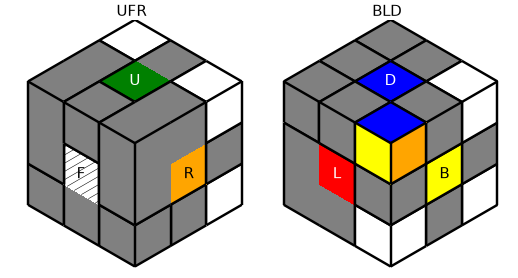

### Case 6

Execute `(M48^((M1 M2)^-1))^-1: L R' U B L U' R' U L' U' R U L U' R L' R2 U L U' R U L' U' R L R' U L' B' U' R L'`.

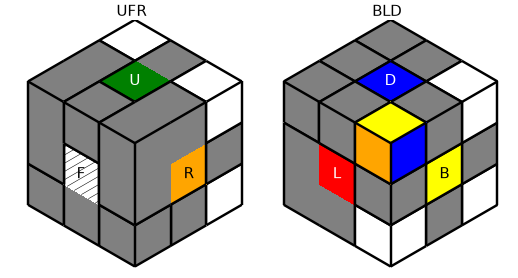

### Case 7

Execute `([M2^-1, M8])^-1: L R2 U L U' R U L' U' R L R2 U L' U' R U L U' R L2`.

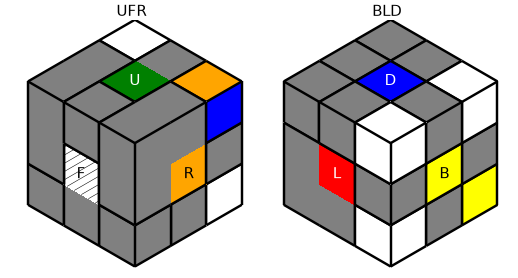

### Case 8

Execute `M48^-1: L2 R2 U L' U' R U L U' R L' R2 U L U' R U L' U' R L'`.

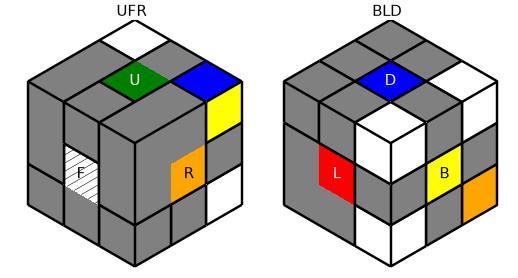

### Case 9

Execute `([M2, M8])^-1: L R2 U L U' R2 L' R' U L U' R' U L' U' R2 L R' U L' U' R L'`.

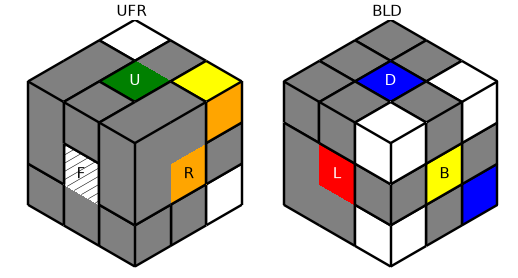

### Case 10

Execute `(M48^(M2^-1))^-1: L R' U L U' R' U L' U' R U L U' R L' R2 U L U' R U L' U' R L R' U L' U' R L'`.

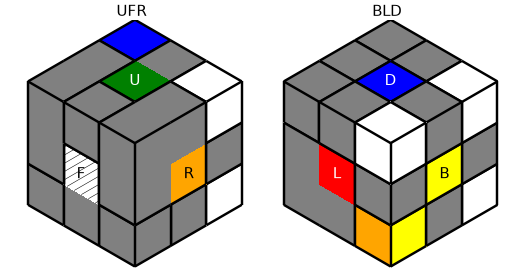

### Case 11

Execute `M48: L R' U L U' R' U L' U' R2 L R' U L' U' R' U L U' R2 L2`.

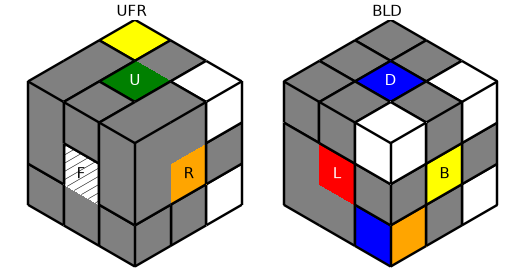

### Case 12

Execute `[M2^-1, M8]: L2 R' U L' U' R' U L U' R2 L' R' U L U' R' U L' U' R2 L'`.

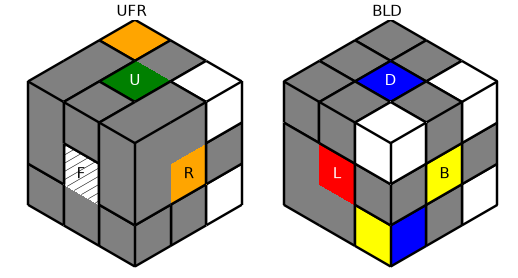

Also correct automatically after this stage: place Corner DBL.

## Stage 9: Solve Corner DBR

This stage has 9 exact cases and 8 instruction families. It reduces the remaining possibilities from 27 to 3.

### Case 1

Skip — already correct

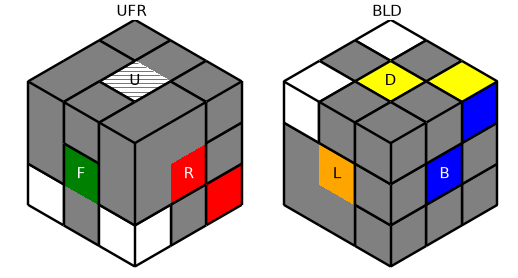

### Case 2

Execute `((M49^-1)^((M9^-1 M10^-1)^-1))^-1: L' R F D' R F' R2 L' R2 F R' F' R F R' F' R' L R F R F' R' F D F' R' L`.

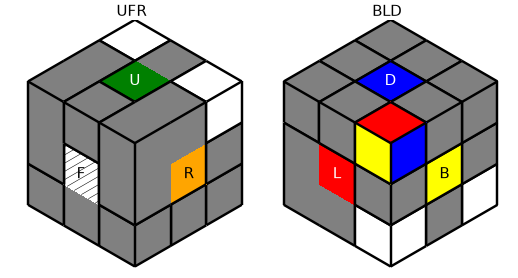

### Case 3

Execute `(M49^((M9^-1 M10^-1)^-1))^-1: L' R F D' F' R F R' F' R' L' R F R F' R' F R F' R2 L R2 F R' D F' R' L`.

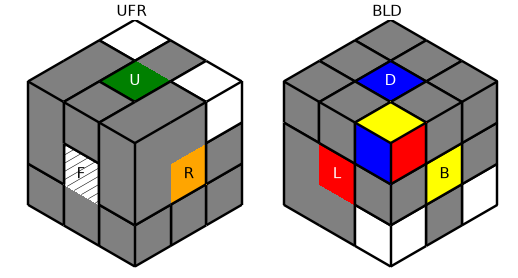

### Case 4

Execute `(M17^-1 M40^-1 M43 M7)^-1: L R2 U2 R U2 R L R2 U L F2 L' F' U2 R U R' F' R2 L2`.

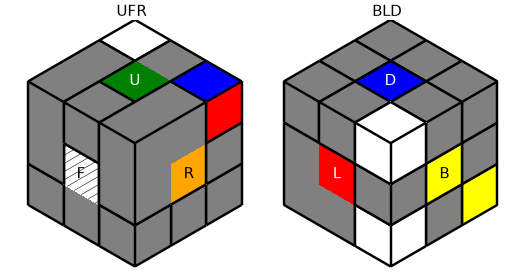

### Case 5

Execute `(M4^-1 M18)^-1: L2 R2 U' R U R L' R' U' R' U R2 L'`.

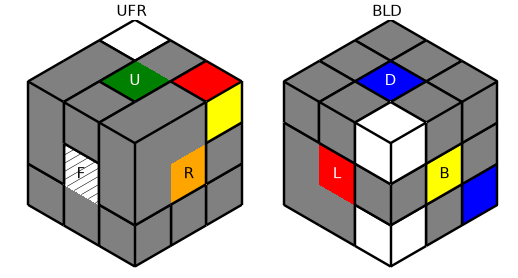

### Case 6

Execute `([M18^-1, M4^-1])^-1: L R2 U' R U R L R2 U' R U R L' R' U' R' U R2 L R' U' R' U R2 L2`.

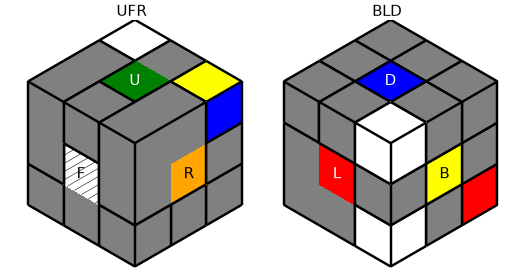

### Case 7

Execute `([M4^-1, M18])^-1: L2 R' U' R' U R2 L' R2 U' R U R L R2 U' R U R L' R' U' R' U R2 L'`.

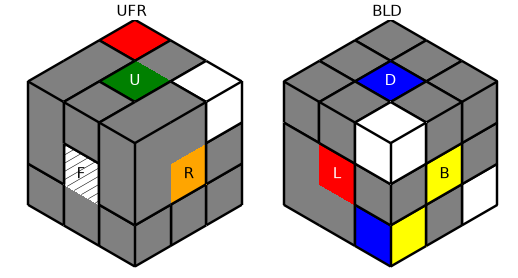

### Case 8

Execute `(M18^-1 M4)^-1: L R2 U' R U R L R' U' R' U R2 L2`.

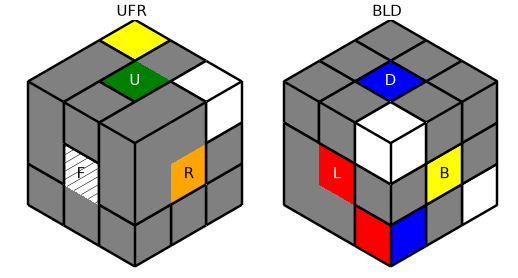

### Case 9

Execute `([M4, M18^-1])^-1: L2 R2 U' R U R L' R' U' R' U R2 L R' U' R' U R2 L' R2 U' R U R L'`.

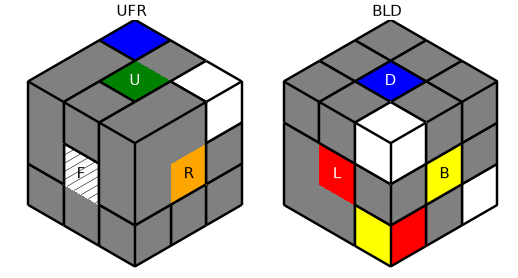

Also correct automatically after this stage: place Corner DBR; place Corner DFL; place Corner DFR.

## Stage 10: Orient Corner DFL

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 3 to 1.

### Case 1

Skip — already correct

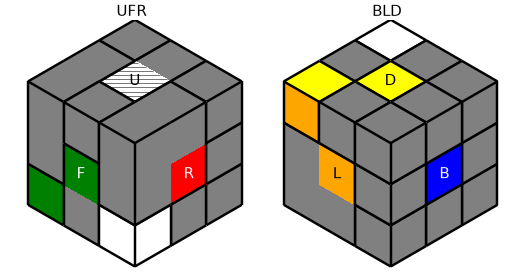

### Case 2

Execute `(((M8^2 M2^-2)^-1)^M8)^-1: L R2 U L U' R U L' U' R L R' U L' U' R' U L U' R2 L2`.

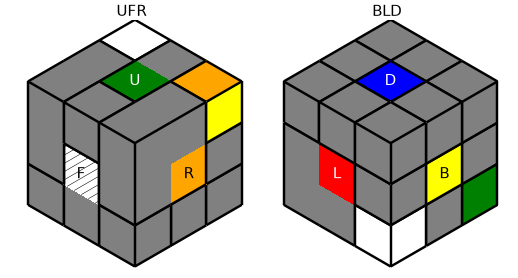

### Case 3

Execute `((M8^2 M2^-2)^M8)^-1: L2 R2 U L' U' R U L U' R L' R' U L U' R' U L' U' R2 L'`.

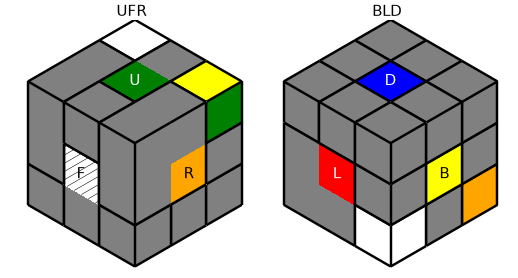

Also correct automatically after this stage: fully solve Corner DFR.

After the final stage every modeled corner and edge sticker is solved. Unmarked center spin and independent virtual-core spin are outside this model.


In [ ]:
repertoire = c.template_human_repertoire(analysis, preference=preference, backend="symbolic", progress=None)
display(Markdown(repertoire.write_guide(diagram_mode=diagram_mode, face_colors=face_colors)))


Optional shape graph. Configure and run the following cell when you want to draw the graph. `graph_view="auto"` draws small graphs and summarizes graphs above 1,000 shapes. Use `"local"` for a bounded neighborhood, or explicitly set `graph_view="full"` to draw every shape. Full layouts of large graphs can be expensive.


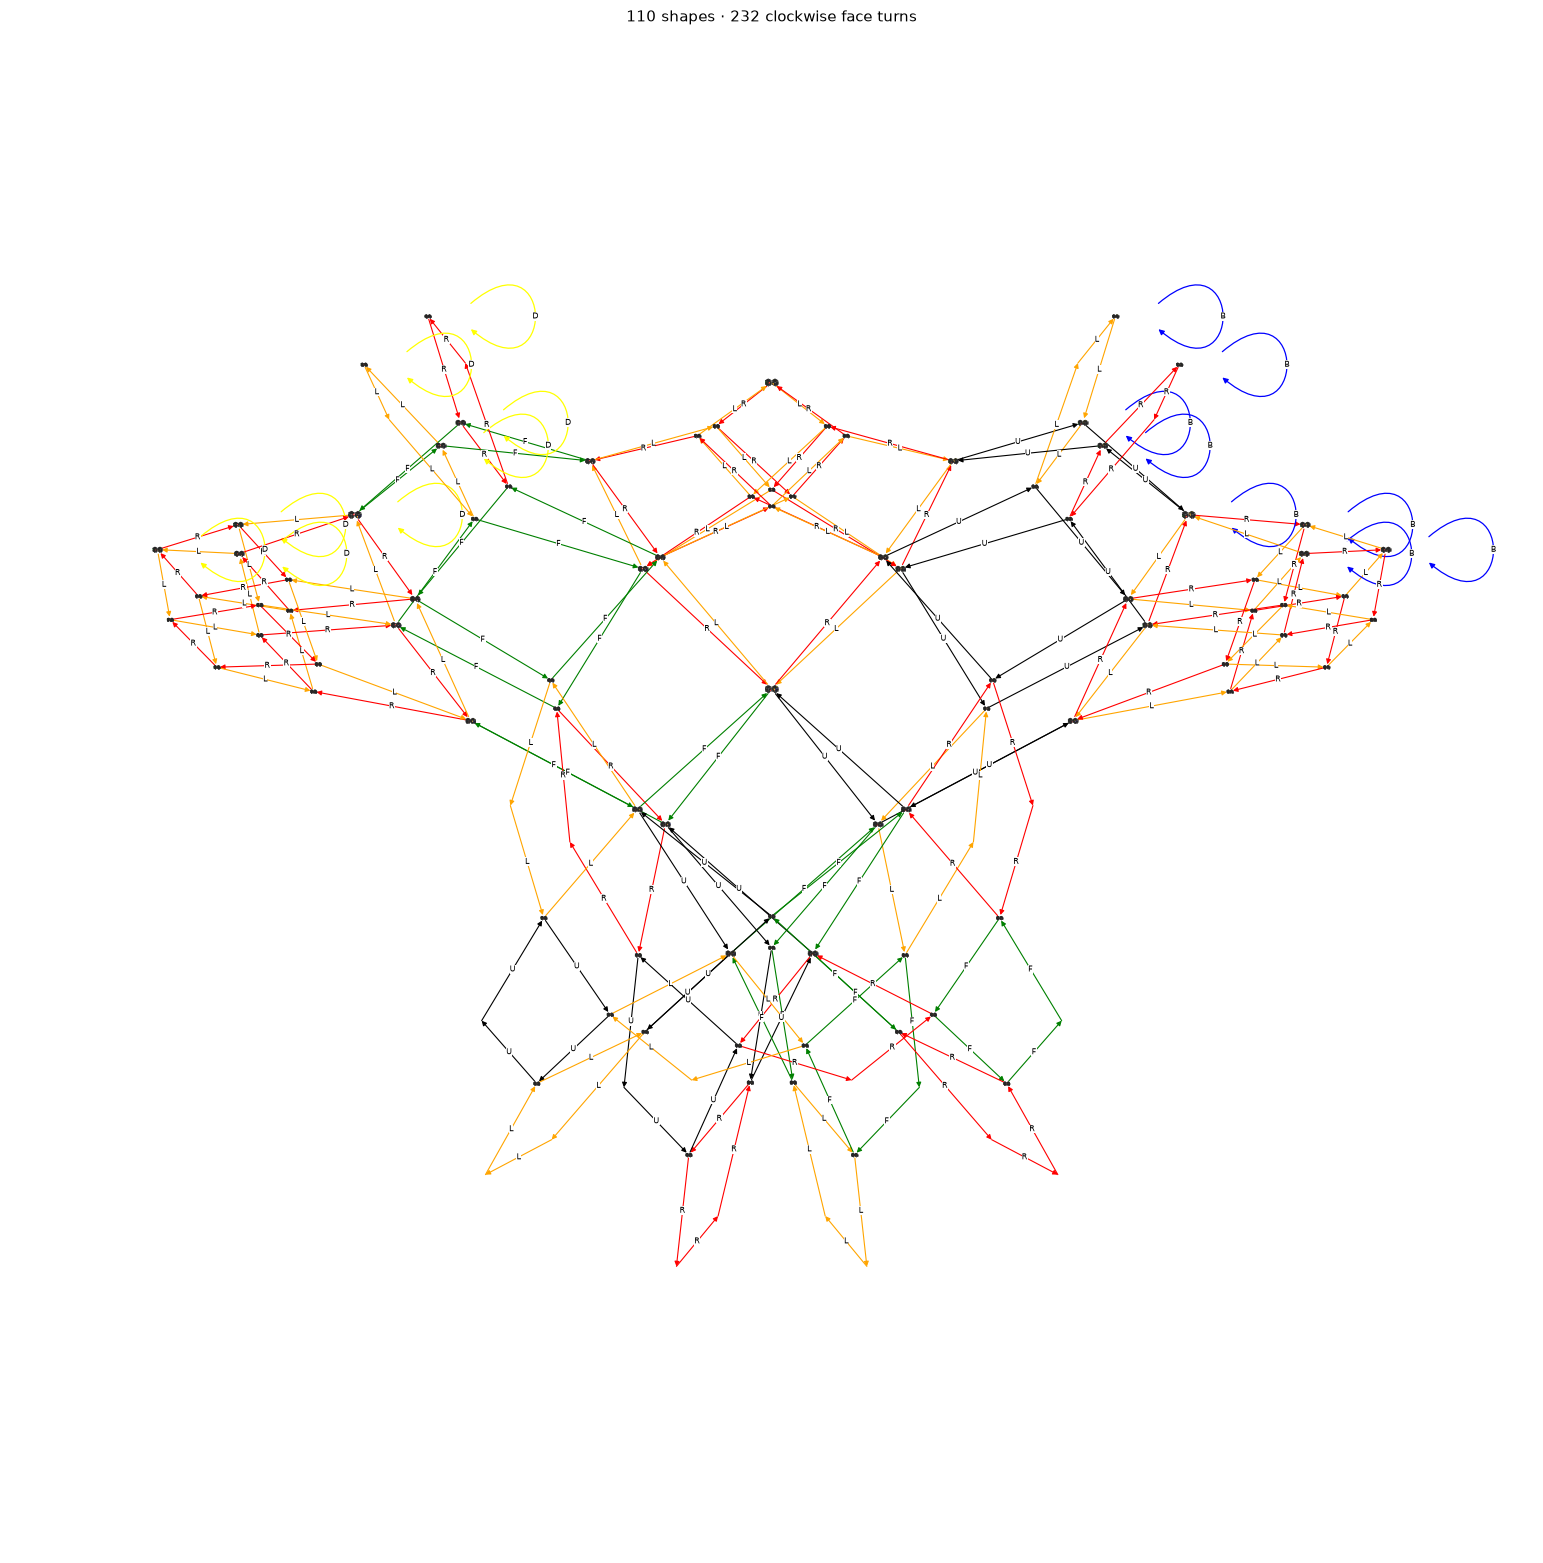

In [ ]:
import matplotlib.pyplot as plt

graph_view = "auto"  # "summary", "local", or explicit "full"
graph_max_vertices = 1000  # full auto drawings and local neighborhoods are bounded
graph_radius = 2  # used only for the local view
graph_layout = "symmetry"
graph_show_shapes = True
graph_edge_labels = True
graph_figsize = None  # automatic; override with (width, height) in inches
graph_shape_size = None  # automatic; override with a width in inches

shape_graph = c.explore(bandage)
graph_figure = c.draw_bandage_graph(
    shape_graph, view=graph_view, max_vertices=graph_max_vertices, radius=graph_radius,
    layout=graph_layout, show_shapes=graph_show_shapes,
    edge_labels=graph_edge_labels, face_colors=face_colors,
    diagram_mode=diagram_mode, figsize=graph_figsize, shape_size=graph_shape_size,
)
display(graph_figure)
plt.close(graph_figure)
